### IMPORT LIBRARIES

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sn
import skimage.io
import os 
import tqdm
import glob
import tensorflow 
import random

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn import metrics
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.resnet50 import ResNet50
from tensorflow.keras.utils import to_categorical
from keras import optimizers

from keras.callbacks import Callback,ModelCheckpoint
from keras.models import Sequential,load_model
from keras.layers import Dense, Dropout
from keras.wrappers.scikit_learn import KerasClassifier
import keras.backend as K

#import tensorflow_addons as tfa
#from tensorflow.keras.metrics import Metric
#from tensorflow_addons.utils.types import AcceptableDTypes, FloatTensorLike
from typeguard import typechecked
from typing import Optional
import tensorflow 

from tqdm import tqdm
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split

from skimage.io import imread, imshow
from skimage.transform import resize
#from skimage.color import grey2rgb

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import InputLayer, BatchNormalization, Dropout, Flatten, Dense, Activation, MaxPool2D, Conv2D
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
from tensorflow.keras.applications.densenet import DenseNet169
from tensorflow.keras.preprocessing.image import load_img, img_to_array
import keras.backend as K

In [13]:
AUTOTUNE = tf.data.experimental.AUTOTUNE
filepath = '../models/mobilenet-localised-100.h5'
datapath = "../localised_reduced/"
batch_size = 128

In [14]:
train_datagen = ImageDataGenerator(rescale = 1./255,                 
        rotation_range=5,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        #zoom_range=0.2,
        validation_split=0.2,
        horizontal_flip=True,
        vertical_flip=True,
        fill_mode='nearest')

test_datagen = ImageDataGenerator(rescale = 1./255)

In [15]:
train_dataset  = train_datagen.flow_from_directory(directory = datapath + "train",
                                                   target_size = (224,224),
                                                   class_mode = 'categorical',
                                                   subset="training",
                                                   batch_size = batch_size)

Found 2402 images belonging to 3 classes.


In [16]:
valid_dataset = train_datagen.flow_from_directory(directory = datapath + "train",
                                                  target_size = (224,224),
                                                  class_mode = 'categorical',
                                                  subset="validation",
                                                  batch_size = batch_size)

Found 599 images belonging to 3 classes.


## feature preprocessing and label encoding.

### MODEL BUILDING

In [17]:
base_model = tf.keras.applications.MobileNetV2(input_shape=(224,224,3), 
                   include_top=False,
                   weights="imagenet")

In [18]:
# Freezing Layers

for layer in base_model.layers:
    layer.trainable=False

In [19]:
# Building Model

model=Sequential()
model.add(base_model)
model.add(Dropout(0.5))
model.add(Flatten())
model.add(BatchNormalization())
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dropout(0.5))
model.add(Dense(32,kernel_initializer='he_uniform'))
model.add(BatchNormalization())
model.add(Activation('relu'))
model.add(Dense(3,activation='softmax'))

In [20]:
# Model Summary

model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 mobilenetv2_1.00_224 (Funct  (None, 7, 7, 1280)       2257984   
 ional)                                                          
                                                                 
 dropout (Dropout)           (None, 7, 7, 1280)        0         
                                                                 
 flatten (Flatten)           (None, 62720)             0         
                                                                 
 batch_normalization (BatchN  (None, 62720)            250880    
 ormalization)                                                   
                                                                 
 dense (Dense)               (None, 32)                2007072   
                                                                 
 batch_normalization_1 (Batc  (None, 32)               1

In [21]:
def f1_score(y_true, y_pred): #taken from old keras source code
    true_positives = K.sum(K.round(K.clip(y_true * y_pred, 0, 1)))
    possible_positives = K.sum(K.round(K.clip(y_true, 0, 1)))
    predicted_positives = K.sum(K.round(K.clip(y_pred, 0, 1)))
    precision = true_positives / (predicted_positives + K.epsilon())
    recall = true_positives / (possible_positives + K.epsilon())
    f1_val = 2*(precision*recall)/(precision+recall+K.epsilon())
    return f1_val

In [22]:
OPT    = tensorflow.keras.optimizers.Adam(lr=0.001)
METRICS = [
      tensorflow.keras.metrics.AUC(name = 'auc'),
      tensorflow.keras.metrics.CategoricalAccuracy(name='accuracy'),
      tensorflow.keras.metrics.Precision(name='precision'),
      tensorflow.keras.metrics.Recall(name='recall'),  
        f1_score,
          ]
model.compile(loss='categorical_crossentropy',
              metrics=METRICS,
              optimizer=OPT)

/opt/conda/envs/mlp/lib/python3.10/site-packages/keras/optimizers/optimizer_v2/adam.py:114: UserWarning: The `lr` argument is deprecated, use `learning_rate` instead.
  super().__init__(name, **kwargs)


In [23]:
# Defining Callbacks
earlystopping = EarlyStopping(monitor = 'val_auc', 
                              mode = 'max' , 
                              patience = 100,
                              verbose = 1)

checkpoint    = ModelCheckpoint(filepath, 
                                monitor = 'val_auc', 
                                mode='max', 
                                save_best_only=True, 
                                save_weights_only=False,
                                verbose = 1)


callback_list = [earlystopping, checkpoint]

In [24]:
model_history=model.fit(train_dataset,
                        validation_data=valid_dataset,
                        epochs = 100,
                        callbacks = callback_list,
                        verbose = 1)

Epoch 1/100
19/19 [==============================] - ETA: 0s - loss: 1.1492 - auc: 0.5659 - accuracy: 0.3801 - precision: 0.4486 - recall: 0.1761 - f1_score: 0.2521
Epoch 1: val_auc improved from -inf to 0.65320, saving model to ../models/mobilenet-localised-100.h5
19/19 [==============================] - 41s 2s/step - loss: 1.1492 - auc: 0.5659 - accuracy: 0.3801 - precision: 0.4486 - recall: 0.1761 - f1_score: 0.2521 - val_loss: 2.5730 - val_auc: 0.6532 - val_accuracy: 0.4708 - val_precision: 0.4722 - val_recall: 0.4674 - val_f1_score: 0.4670
Epoch 2/100
19/19 [==============================] - ETA: 0s - loss: 1.0729 - auc: 0.6255 - accuracy: 0.4430 - precision: 0.5202 - recall: 0.1932 - f1_score: 0.2810
Epoch 2: val_auc improved from 0.65320 to 0.70141, saving model to ../models/mobilenet-localised-100.h5
19/19 [==============================] - 32s 2s/step - loss: 1.0729 - auc: 0.6255 - accuracy: 0.4430 - precision: 0.5202 - recall: 0.1932 - f1_score: 0.2810 - val_loss: 1.2095 - va

19/19 [==============================] - 32s 2s/step - loss: 0.8925 - auc: 0.7629 - accuracy: 0.5699 - precision: 0.6604 - recall: 0.3780 - f1_score: 0.4804 - val_loss: 0.8049 - val_auc: 0.8396 - val_accuracy: 0.6644 - val_precision: 0.7938 - val_recall: 0.4307 - val_f1_score: 0.5582
Epoch 17/100
19/19 [==============================] - ETA: 0s - loss: 0.8971 - auc: 0.7637 - accuracy: 0.5733 - precision: 0.6555 - recall: 0.3826 - f1_score: 0.4829
Epoch 17: val_auc did not improve from 0.83957
19/19 [==============================] - 32s 2s/step - loss: 0.8971 - auc: 0.7637 - accuracy: 0.5733 - precision: 0.6555 - recall: 0.3826 - f1_score: 0.4829 - val_loss: 0.8272 - val_auc: 0.8221 - val_accuracy: 0.6628 - val_precision: 0.7672 - val_recall: 0.4290 - val_f1_score: 0.5500
Epoch 18/100
19/19 [==============================] - ETA: 0s - loss: 0.8839 - auc: 0.7702 - accuracy: 0.5845 - precision: 0.6681 - recall: 0.3980 - f1_score: 0.4985
Epoch 18: val_auc did not improve from 0.83957
19/1

19/19 [==============================] - 32s 2s/step - loss: 0.7947 - auc: 0.8174 - accuracy: 0.6224 - precision: 0.6925 - recall: 0.4950 - f1_score: 0.5774 - val_loss: 0.7389 - val_auc: 0.8540 - val_accuracy: 0.6644 - val_precision: 0.7424 - val_recall: 0.5292 - val_f1_score: 0.6234
Epoch 33/100
19/19 [==============================] - ETA: 0s - loss: 0.8221 - auc: 0.8053 - accuracy: 0.6132 - precision: 0.6686 - recall: 0.4904 - f1_score: 0.5658
Epoch 33: val_auc did not improve from 0.86845
19/19 [==============================] - 32s 2s/step - loss: 0.8221 - auc: 0.8053 - accuracy: 0.6132 - precision: 0.6686 - recall: 0.4904 - f1_score: 0.5658 - val_loss: 0.7418 - val_auc: 0.8537 - val_accuracy: 0.6928 - val_precision: 0.7564 - val_recall: 0.5442 - val_f1_score: 0.6299
Epoch 34/100
19/19 [==============================] - ETA: 0s - loss: 0.7804 - auc: 0.8259 - accuracy: 0.6399 - precision: 0.7115 - recall: 0.5175 - f1_score: 0.5994
Epoch 34: val_auc did not improve from 0.86845
19/1

Epoch 49/100
19/19 [==============================] - ETA: 0s - loss: 0.7209 - auc: 0.8551 - accuracy: 0.6790 - precision: 0.7396 - recall: 0.5828 - f1_score: 0.6517
Epoch 49: val_auc did not improve from 0.89616
19/19 [==============================] - 32s 2s/step - loss: 0.7209 - auc: 0.8551 - accuracy: 0.6790 - precision: 0.7396 - recall: 0.5828 - f1_score: 0.6517 - val_loss: 0.6991 - val_auc: 0.8693 - val_accuracy: 0.7145 - val_precision: 0.7624 - val_recall: 0.5893 - val_f1_score: 0.6653
Epoch 50/100
19/19 [==============================] - ETA: 0s - loss: 0.7404 - auc: 0.8486 - accuracy: 0.6728 - precision: 0.7258 - recall: 0.5674 - f1_score: 0.6359
Epoch 50: val_auc did not improve from 0.89616
19/19 [==============================] - 32s 2s/step - loss: 0.7404 - auc: 0.8486 - accuracy: 0.6728 - precision: 0.7258 - recall: 0.5674 - f1_score: 0.6359 - val_loss: 0.6750 - val_auc: 0.8813 - val_accuracy: 0.6995 - val_precision: 0.7575 - val_recall: 0.5893 - val_f1_score: 0.6618
Epoc

Epoch 66/100
19/19 [==============================] - ETA: 0s - loss: 0.6812 - auc: 0.8700 - accuracy: 0.6919 - precision: 0.7458 - recall: 0.6082 - f1_score: 0.6699
Epoch 66: val_auc did not improve from 0.89616
19/19 [==============================] - 32s 2s/step - loss: 0.6812 - auc: 0.8700 - accuracy: 0.6919 - precision: 0.7458 - recall: 0.6082 - f1_score: 0.6699 - val_loss: 0.6721 - val_auc: 0.8794 - val_accuracy: 0.7312 - val_precision: 0.7771 - val_recall: 0.6578 - val_f1_score: 0.7094
Epoch 67/100
19/19 [==============================] - ETA: 0s - loss: 0.6783 - auc: 0.8726 - accuracy: 0.6986 - precision: 0.7517 - recall: 0.6137 - f1_score: 0.6753
Epoch 67: val_auc did not improve from 0.89616
19/19 [==============================] - 32s 2s/step - loss: 0.6783 - auc: 0.8726 - accuracy: 0.6986 - precision: 0.7517 - recall: 0.6137 - f1_score: 0.6753 - val_loss: 0.6551 - val_auc: 0.8864 - val_accuracy: 0.7062 - val_precision: 0.7686 - val_recall: 0.6544 - val_f1_score: 0.7115
Epoc

19/19 [==============================] - 33s 2s/step - loss: 0.6727 - auc: 0.8749 - accuracy: 0.7057 - precision: 0.7523 - recall: 0.6336 - f1_score: 0.6875 - val_loss: 0.6196 - val_auc: 0.9011 - val_accuracy: 0.7412 - val_precision: 0.7843 - val_recall: 0.6678 - val_f1_score: 0.7180
Epoch 83/100
19/19 [==============================] - ETA: 0s - loss: 0.6442 - auc: 0.8860 - accuracy: 0.7119 - precision: 0.7634 - recall: 0.6515 - f1_score: 0.7039
Epoch 83: val_auc improved from 0.90109 to 0.90282, saving model to ../models/mobilenet-localised-100.h5
19/19 [==============================] - 33s 2s/step - loss: 0.6442 - auc: 0.8860 - accuracy: 0.7119 - precision: 0.7634 - recall: 0.6515 - f1_score: 0.7039 - val_loss: 0.6101 - val_auc: 0.9028 - val_accuracy: 0.7446 - val_precision: 0.7980 - val_recall: 0.6661 - val_f1_score: 0.7274
Epoch 84/100
19/19 [==============================] - ETA: 0s - loss: 0.6763 - auc: 0.8742 - accuracy: 0.7057 - precision: 0.7468 - recall: 0.6349 - f1_score: 

Epoch 99/100
19/19 [==============================] - ETA: 0s - loss: 0.6434 - auc: 0.8868 - accuracy: 0.7236 - precision: 0.7581 - recall: 0.6719 - f1_score: 0.7131
Epoch 99: val_auc did not improve from 0.91076
19/19 [==============================] - 32s 2s/step - loss: 0.6434 - auc: 0.8868 - accuracy: 0.7236 - precision: 0.7581 - recall: 0.6719 - f1_score: 0.7131 - val_loss: 0.6307 - val_auc: 0.8946 - val_accuracy: 0.7179 - val_precision: 0.7638 - val_recall: 0.6694 - val_f1_score: 0.7153
Epoch 100/100
19/19 [==============================] - ETA: 0s - loss: 0.6618 - auc: 0.8788 - accuracy: 0.7073 - precision: 0.7496 - recall: 0.6470 - f1_score: 0.6941
Epoch 100: val_auc improved from 0.91076 to 0.91114, saving model to ../models/mobilenet-localised-100.h5
19/19 [==============================] - 32s 2s/step - loss: 0.6618 - auc: 0.8788 - accuracy: 0.7073 - precision: 0.7496 - recall: 0.6470 - f1_score: 0.6941 - val_loss: 0.5902 - val_auc: 0.9111 - val_accuracy: 0.7529 - val_precis

In [25]:
from tensorflow.keras.utils import to_categorical, plot_model
#plot_model(model, to_file='NN-mnist.png', show_shapes=True)

In [26]:
#model.load_weights("/kaggle/input/zahaimar-22/zahaimar_v2.h5")

In [27]:
#model.compile(optimizer='rmsprop', loss='categorical_crossentropy',metrics=METRICS)

In [28]:
#test_dataset = tf.keras.preprocessing.image_dataset_from_directory("../input/alzheimers-dataset-4-class-of-images/Alzheimer_s Dataset/test",
##                                                            shuffle=False,
#                                                            image_size=(224,224),
#                                                            batch_size=32,
#)

best_model = tf.keras.models.load_model('../models/mobilenet-localised-100.h5', custom_objects={"f1_score": f1_score})

test_dataset = test_datagen.flow_from_directory(directory = datapath + "test",
                                                  target_size = (224,224),
                                                  class_mode = 'categorical'
                                                  )

Found 739 images belonging to 3 classes.


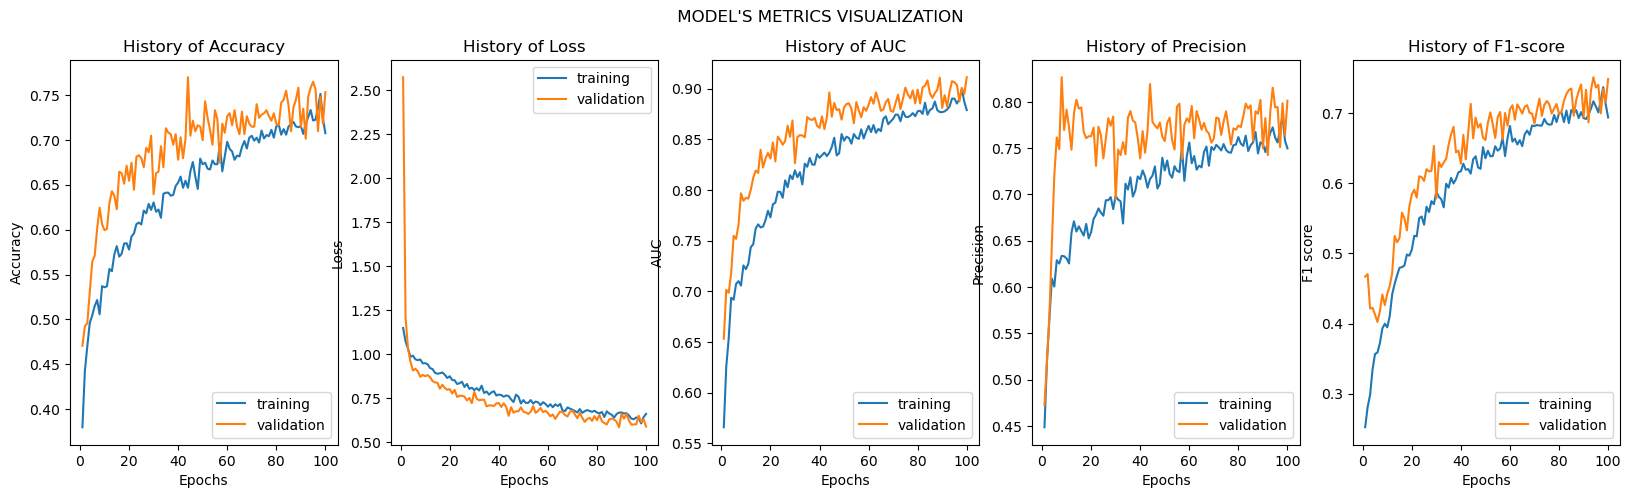

In [29]:
#%% PLOTTING RESULTS (Train vs Validation FOLDER 1)

def Train_Val_Plot(acc,val_acc,loss,val_loss,auc,val_auc,precision,val_precision,f1,val_f1):
    
    fig, (ax1, ax2,ax3,ax4,ax5) = plt.subplots(1,5, figsize= (20,5))
    fig.suptitle(" MODEL'S METRICS VISUALIZATION ")

    ax1.plot(range(1, len(acc) + 1), acc)
    ax1.plot(range(1, len(val_acc) + 1), val_acc)
    ax1.set_title('History of Accuracy')
    ax1.set_xlabel('Epochs')
    ax1.set_ylabel('Accuracy')
    ax1.legend(['training', 'validation'])


    ax2.plot(range(1, len(loss) + 1), loss)
    ax2.plot(range(1, len(val_loss) + 1), val_loss)
    ax2.set_title('History of Loss')
    ax2.set_xlabel('Epochs')
    ax2.set_ylabel('Loss')
    ax2.legend(['training', 'validation'])
    
    ax3.plot(range(1, len(auc) + 1), auc)
    ax3.plot(range(1, len(val_auc) + 1), val_auc)
    ax3.set_title('History of AUC')
    ax3.set_xlabel('Epochs')
    ax3.set_ylabel('AUC')
    ax3.legend(['training', 'validation'])
    
    ax4.plot(range(1, len(precision) + 1), precision)
    ax4.plot(range(1, len(val_precision) + 1), val_precision)
    ax4.set_title('History of Precision')
    ax4.set_xlabel('Epochs')
    ax4.set_ylabel('Precision')
    ax4.legend(['training', 'validation'])
    
    ax5.plot(range(1, len(f1) + 1), f1)
    ax5.plot(range(1, len(val_f1) + 1), val_f1)
    ax5.set_title('History of F1-score')
    ax5.set_xlabel('Epochs')
    ax5.set_ylabel('F1 score')
    ax5.legend(['training', 'validation'])


    plt.show()
    

Train_Val_Plot(model_history.history['accuracy'],model_history.history['val_accuracy'],
               model_history.history['loss'],model_history.history['val_loss'],
               model_history.history['auc'],model_history.history['val_auc'],
               model_history.history['precision'],model_history.history['val_precision'],
               model_history.history['f1_score'],model_history.history['val_f1_score']
              )

In [30]:
scores = best_model.evaluate(test_dataset)

24/24 [==============================] - 2s 35ms/step - loss: 0.6327 - auc: 0.8914 - accuracy: 0.7307 - precision: 0.7620 - recall: 0.6847 - f1_score: 0.7239


In [31]:
print(scores)
# print("Accuracy = ", scores[1])
# print("Precision = ", scores[2])
# print("Recall = ", scores[3])
# print("AUC = ", scores[4])
# print("F1_score = ", scores[5])

[0.6326776146888733, 0.8913967609405518, 0.7307171821594238, 0.7620481848716736, 0.6847090721130371, 0.7238531708717346]


# Test on the DataSet

In [ ]:
# Test Case 1: Alzheimers

dic = test_dataset.class_indices
idc = {k:v for v, k in dic.items()}

cog_dir = os.path.join(datapath + "test", random.choice(os.listdir(datapath + "test")))
img_dir = os.path.join(cog_dir, random.choice(os.listdir(cog_dir)))
print(f"Loaded {img_dir}")

img = load_img(img_dir, target_size = (224,224,3))
img = img_to_array(img)
img = img/255
plt.imshow(img)
plt.axis('off')
img = np.expand_dims(img,axis=0)

class_index = np.argmax(model.predict(img),axis=1)[0]

probability = round(np.max(model.predict(img)*100),2)


print(probability, '% chances are there that the image is', idc[class_index])

# Confusion Matrix

In [ ]:
true_classes = test_dataset.classes
class_indices = test_dataset.class_indices
class_indices = dict((v,k) for k,v in class_indices.items())

preds = model.predict(test_dataset)
pred_classes = np.argmax(preds, axis=1)

In [ ]:
print(train_dataset.class_indices.keys())

In [ ]:
import seaborn as sns
from sklearn.metrics import confusion_matrix

# Get the names of the ten classes
class_names = test_dataset.class_indices.keys()

def plot_heatmap(y_true, y_pred):
    cm = confusion_matrix(y_true, y_pred)
    sns.heatmap(
        cm, 
        annot=True, 
        square=True, 
        fmt='d', 
        cmap=plt.cm.Blues,
        cbar=False,
    )

plt.figure()
plot_heatmap(true_classes, pred_classes)    

plt.show()

# 